# Introduction to CNN

- Specialised type of neural network designed for processing grid data, such as images
- Particularly effective for image-related tasks like classification, object detection and segmentation


- ## Why CNN for image processing
  - **Spatial Hierarchies:** CNN capture spatial and hierarchical patterns in images
    - Convolutional layers extract features like edges, textures and complex structures
  - **Parameter Efficiency:** Unlike fully connected, CNNs use fewer parameters due to shared weights reducing computation and memory requirements

## CNN Architecture (Key Components)
- **Convolutional layer**
  - Performs convolution operations to extract features
  - `kernal/filter`
    - A small matrix (eg 3x3) that slides over the input image to detect patterns
  - `Output`
    - Features maps highlighting specific pattrens in the input
  
- **Pooling layers** : Downsample feature maps to reduce dimentions and computation
  - Types
    - `Max-Pooling`: Takes the maximum value in a region
    - `Average Pooling`: Takes the average value in a region

- **Fully Connected Layers** : Combine extracted features for final predictions
  - Act as a classifier in the network


#### Basic CNN Workflow
`Input image` -> `Convolution` -> `Activation` -> `Pooling` -> `FCNN` -> `oUTPUT`

---

#### Key Advantages of CNN over Fully Connected Networks for Images
- **Translation Invariance**: CNNs can detect patterns irrespective of their position in the image
- **Reduced Parameters** : Shared weights and local connectivity make CNNs computationally effient
- **Automatic Feature Extraction** : CNNs learn to identify meaningful patters like edges, shaoes and textures directly from data

---

### Hands-On
Objective: Visualize images in a dataset, explore their pixel data and set up an enviroment for building CNNs using TensorFlow or PyTorch

- **Datasets**: Provide access to framous datasets like CIFAT
- **Transforms**: provides the utily to preprocess and transform image data such as converting images to tensor

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

Defining the transfomation to convert images form  the dataset to pytorch tensor, which is necessary for using the data in pytorch model

In [9]:
# Load Dataset
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download = True)

- `1,5`: it creates the fig with 1 row and 5 columns of subplots to display images

- `figsize(12,3)`: figsize define the size of the figure 12 inches wide, 3 inches height
- Here we are displaying the images using imshow
- Inside it permute() method, which reorders the dimention from `[channels, height and width]` to `[heigh, width, channels]`



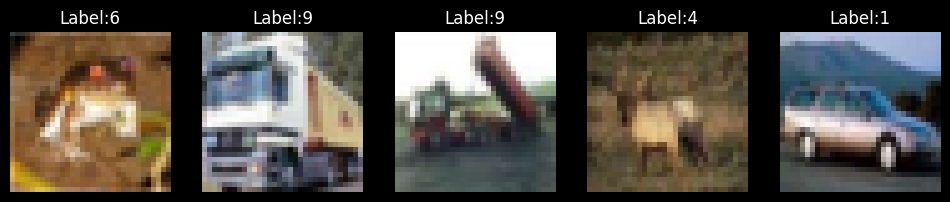

In [10]:
# Visualise sample images
fig, axes = plt.subplots(1,5, figsize=(12,3))


for i in range(5):
  image, label = train_dataset[i]

  # Normalize the image data to the range [0, 1]
  #image = image / 255.0

  # Here we are displaying the images using imshow
  axes[i].imshow(image.permute(1,2,0))
  axes[i].axis('off') # hide the axes for clearer display of image
  axes[i].set_title(f"Label:{label}") # set the title of each subplot to the label of image

plt.show()

displays the pixel values for the fisrt image

In [11]:
# Display pixel values fro the first image
image , label = train_dataset[0] # Retrives the first image and its label from the training dataset
print(f"label:{label}")# label of the first image
print(f"Image Shape: {image.shape}") # shape of the first image
print("Pixel Values:")
print(image)

label:6
Image Shape: torch.Size([3, 32, 32])
Pixel Values:
tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],

## Tensorflow Model

In [4]:
import tensorflow as tf

- `Sequential` means: each layer will run sequantially one at time
- 1st Layer: `Conv2D`/ Convolutional layer, with 32 filters, 3x3 kernal and relu activation
- 2nd Layer: `MaxPooling2D`, layer with 2x2 pooling window, to reduct the spatial dimention fo the previous input
- 3rd Layer: `Flatten`: flattens the 2d feature map into a 1d vector
- 4th Layer: `Dense` for fully connected layer with 128 neurons
- 5th Layer: `Dense` with 10 neurons, representing the 10  classification units, softmax is for classification here

Note: When using CNN based model, use input shape object as the first layer in the model

In [5]:
# Define a simple CNN Model/network
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation ='relu', input_shape= (32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Tensorflow CNN model is ready")

C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Tensorflow CNN model is ready


## PyTorch Model
- `torch.nn` provides the tools in pytorch to build neural network

In [6]:
import torch.nn as nn

In [7]:
# Define a simple CNN model
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(3,32, kernel_size=3)
    self.pool = nn.MaxPool2d(2,2)
    self.fc1 = nn.Linear(32*15*15,128)
    self.fc2 = nn.Linear(128,10)

  def forward(self, x):
    x = F.relu(self.conv1(x))

    # appling max pooing
    x = self.pool(x)

    # Flatten the feature map
    x = x.view(-1, 32*15*15)

    # these lines passes data to last to fcnn layers
    x = F.relu(self.fc1(x))
    x = self.fc2(x)

    return x

# Create an instance of the model
model = SimpleCNN()

print("PyTorch CNN model is ready")

PyTorch CNN model is ready
